# Main Model - Kathmandu AQI Project

## 1. Load data, define features and both targets

In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/kathmandu_features.csv")
df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])
df = df.sort_values("datetime_utc").reset_index(drop=True)

target_column = "target_pm25_next_1h"
feature_columns = [col for col in df.columns if col not in ["datetime_utc", target_column]]

X = df[feature_columns]
current_pm25 = df["pm25"]
y_absolute = df[target_column]
y_delta = y_absolute - current_pm25
dates = df["datetime_utc"]

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print(f"Features ({len(feature_columns)}): {feature_columns}")
print(f"Rows: {len(df)}")

Features (32): ['pm25', 'relativehumidity', 'temperature', 'um003', 'was_missing', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'pm25_lag_1h', 'pm25_lag_2h', 'pm25_lag_6h', 'pm25_lag_7h', 'pm25_lag_8h', 'pm25_lag_9h', 'pm25_lag_24h', 'pm25_lag_48h', 'pm25_rolling_mean_6h', 'pm25_rolling_std_6h', 'pm25_rolling_mean_24h', 'pm25_rolling_std_24h', 'WS10M', 'WD10M', 'PRECTOTCORR', 'wind_dir_sin', 'wind_dir_cos', 'station_mid_baneshwor', 'station_teku']
Rows: 8343


## 2. Train XGBoost on the delta target, per fold


In [10]:
xgb_results = []
xgb_predictions = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_delta_train = y_delta.iloc[train_idx]
    y_absolute_test = y_absolute.iloc[test_idx]
    current_pm25_test = current_pm25.iloc[test_idx]
    dates_test = dates.iloc[test_idx]

    # Drop rows where the delta target itself is NaN (can't train on a missing target)
    train_valid_mask = ~y_delta_train.isna()
    X_train_valid = X_train[train_valid_mask]
    y_delta_train_valid = y_delta_train[train_valid_mask]

    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train_valid, y_delta_train_valid)

    predicted_delta = model.predict(X_test)
    predicted_absolute = current_pm25_test.values + predicted_delta

    # current_pm25_test can be NaN for some rows; exclude those from scoring
    valid_mask = ~np.isnan(predicted_absolute)

    rmse = np.sqrt(mean_squared_error(y_absolute_test[valid_mask], predicted_absolute[valid_mask]))
    mae = mean_absolute_error(y_absolute_test[valid_mask], predicted_absolute[valid_mask])
    r2 = r2_score(y_absolute_test[valid_mask], predicted_absolute[valid_mask])

    xgb_results.append({"fold": fold_num, "rmse_xgb": rmse, "mae_xgb": mae, "r2_xgb": r2})
    xgb_predictions.append({
        "fold": fold_num, "dates": dates_test[valid_mask],
        "y_actual": y_absolute_test[valid_mask], "y_pred": predicted_absolute[valid_mask],
    })

    print(f"Fold {fold_num} ({dates_test.min().date()} to {dates_test.max().date()}): "
          f"RMSE={rmse:.2f} MAE={mae:.2f} R2={r2:.3f}")

xgb_df = pd.DataFrame(xgb_results)

Fold 1 (2025-12-24 to 2026-01-30): RMSE=20.89 MAE=13.93 R2=0.753
Fold 2 (2026-01-30 to 2026-04-04): RMSE=15.47 MAE=9.70 R2=0.818
Fold 3 (2026-04-04 to 2026-06-06): RMSE=17.42 MAE=10.11 R2=0.853
Fold 4 (2026-06-06 to 2026-07-30): RMSE=7.39 MAE=4.61 R2=0.799
Fold 5 (2026-07-30 to 2026-09-03): RMSE=6.53 MAE=4.28 R2=0.637


## 3. Recompute persistence and delta-target Random Forest on the same folds


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

persist_results = []
rf_delta_results = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_delta_train = y_delta.iloc[train_idx]
    y_absolute_test = y_absolute.iloc[test_idx]
    current_pm25_test = current_pm25.iloc[test_idx]

    # --- Persistence ---
    valid_mask_p = ~current_pm25_test.isna()
    rmse_p = np.sqrt(mean_squared_error(y_absolute_test[valid_mask_p], current_pm25_test[valid_mask_p]))
    r2_p = r2_score(y_absolute_test[valid_mask_p], current_pm25_test[valid_mask_p])
    persist_results.append({"fold": fold_num, "rmse_persist": rmse_p, "r2_persist": r2_p})

    # --- Random Forest, delta target ---
    train_valid_mask = ~y_delta_train.isna()
    X_train_valid = X_train[train_valid_mask]
    y_delta_train_valid = y_delta_train[train_valid_mask]

    imputer = SimpleImputer(strategy="median")
    X_train_imputed = imputer.fit_transform(X_train_valid)
    X_test_imputed = imputer.transform(X_test)

    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    rf.fit(X_train_imputed, y_delta_train_valid)
    rf_pred_delta = rf.predict(X_test_imputed)
    rf_pred_absolute = current_pm25_test.values + rf_pred_delta

    valid_mask_rf = ~np.isnan(rf_pred_absolute)
    rmse_rf = np.sqrt(mean_squared_error(y_absolute_test[valid_mask_rf], rf_pred_absolute[valid_mask_rf]))
    r2_rf = r2_score(y_absolute_test[valid_mask_rf], rf_pred_absolute[valid_mask_rf])
    rf_delta_results.append({"fold": fold_num, "rmse_rf_delta": rmse_rf, "r2_rf_delta": r2_rf})

persist_df = pd.DataFrame(persist_results)
rf_delta_df = pd.DataFrame(rf_delta_results)

## 4. Final three-way comparison: XGBoost vs. Random Forest (delta) vs. Persistence

In [ ]:
final = xgb_df.merge(rf_delta_df, on="fold").merge(persist_df, on="fold")

print(final[["fold", "rmse_xgb", "rmse_rf_delta", "rmse_persist"]].to_string(index=False))
print()
print(final[["fold", "r2_xgb", "r2_rf_delta", "r2_persist"]].to_string(index=False))

print()
print("=== AVERAGES ===")
print(f"XGBoost (delta target)      : RMSE={final['rmse_xgb'].mean():.2f}  R2={final['r2_xgb'].mean():.3f}")
print(f"Random Forest (delta target): RMSE={final['rmse_rf_delta'].mean():.2f}  R2={final['r2_rf_delta'].mean():.3f}")
print(f"Naive persistence           : RMSE={final['rmse_persist'].mean():.2f}  R2={final['r2_persist'].mean():.3f}")

xgb_vs_persist = (1 - final['rmse_xgb'].mean() / final['rmse_persist'].mean()) * 100
xgb_vs_rf = (1 - final['rmse_xgb'].mean() / final['rmse_rf_delta'].mean()) * 100
print(f"\nXGBoost improvement over persistence: {xgb_vs_persist:.1f}%")
print(f"XGBoost improvement over RF (delta): {xgb_vs_rf:.1f}%")

if final['rmse_xgb'].mean() < final['rmse_persist'].mean():
    print("\n XGBoost BEATS naive persistence — viable as the main model.")
else:
    print("\n XGBoost still does not beat naive persistence on average.")

 fold  rmse_xgb  rmse_rf_delta  rmse_persist
    1 20.890684      20.516389     25.797088
    2 15.466777      19.586297     18.837901
    3 17.419423      19.172067     13.157190
    4  7.394723      12.838388      7.738198
    5  6.528815       6.306154      7.025198

 fold   r2_xgb  r2_rf_delta  r2_persist
    1 0.752592     0.761378    0.622732
    2 0.817900     0.707979    0.729869
    3 0.852980     0.821908    0.916125
    4 0.798507     0.392652    0.779354
    5 0.636785     0.661137    0.579455

=== AVERAGES ===
XGBoost (delta target)      : RMSE=13.54  R2=0.772
Random Forest (delta target): RMSE=15.68  R2=0.669
Naive persistence           : RMSE=14.51  R2=0.726

XGBoost improvement over persistence: 6.7%
XGBoost improvement over RF (delta): 13.7%

✅ XGBoost BEATS naive persistence — viable as the main model.


## 5. RMSE per fold — all three approaches

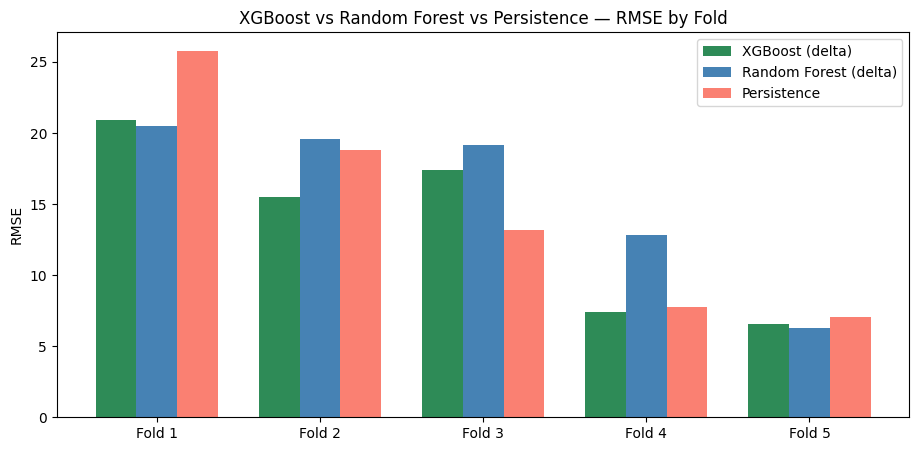

In [ ]:
x = np.arange(n_splits)
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, final["rmse_xgb"], width, label="XGBoost (delta)", color="seagreen")
plt.bar(x, final["rmse_rf_delta"], width, label="Random Forest (delta)", color="steelblue")
plt.bar(x + width, final["rmse_persist"], width, label="Persistence", color="salmon")
plt.xticks(x, [f"Fold {i+1}" for i in range(n_splits)])
plt.ylabel("RMSE")
plt.title("XGBoost vs Random Forest vs Persistence - RMSE by Fold")
plt.legend()
plt.show()

## 6. Predicted vs actual, per fold (XGBoost)

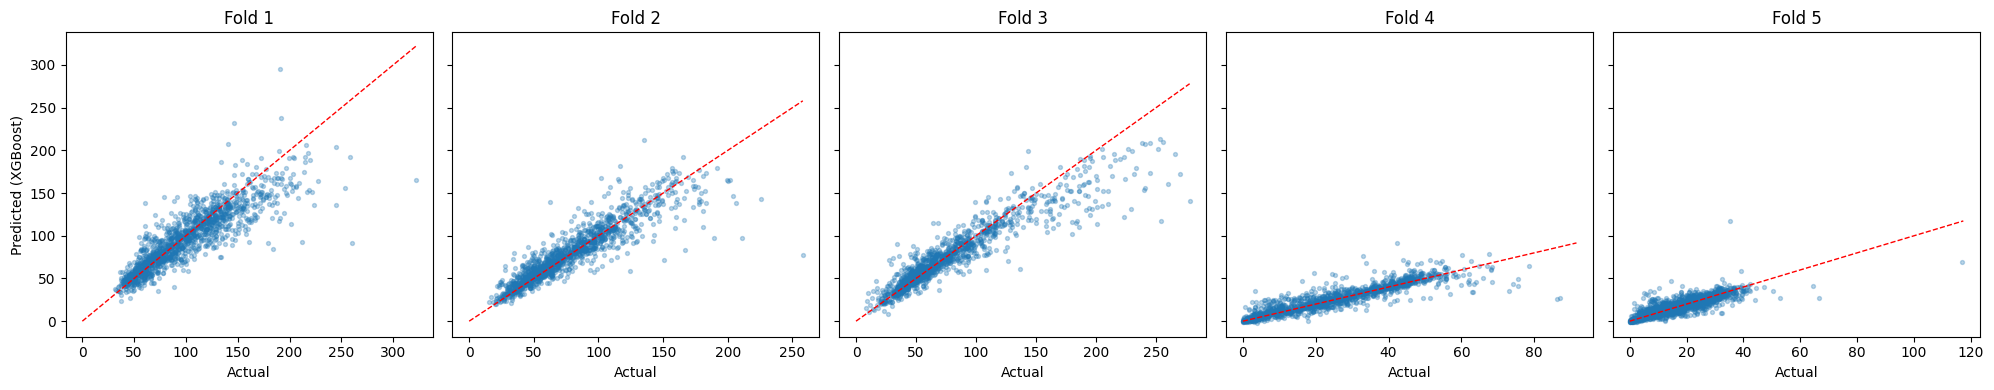

In [14]:
fig, axes = plt.subplots(1, n_splits, figsize=(20, 4), sharey=True)

for i, fold_data in enumerate(xgb_predictions):
    ax = axes[i]
    ax.scatter(fold_data["y_actual"], fold_data["y_pred"], alpha=0.3, s=8)
    lims = [0, max(fold_data["y_actual"].max(), fold_data["y_pred"].max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(f"Fold {fold_data['fold']}")
    ax.set_xlabel("Actual")
    if i == 0:
        ax.set_ylabel("Predicted (XGBoost)")

plt.tight_layout()
plt.show()

## 7. Feature importance (XGBoost, trained on full data)

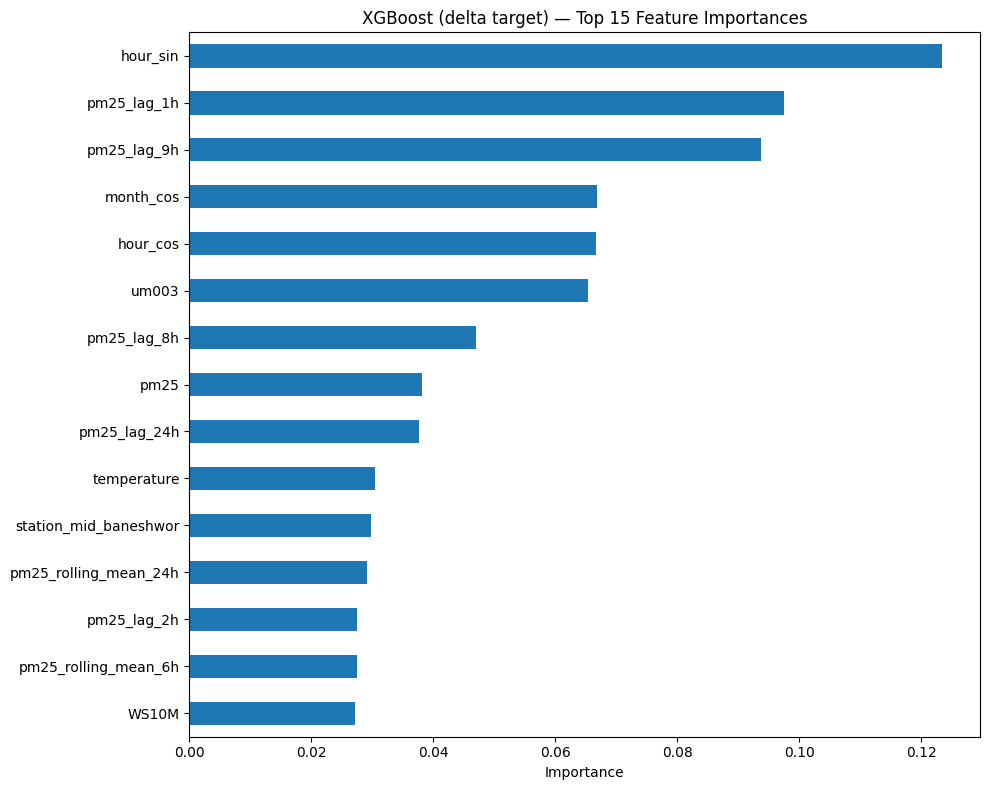

hour_sin                 0.123485
pm25_lag_1h              0.097454
pm25_lag_9h              0.093689
month_cos                0.066859
hour_cos                 0.066680
um003                    0.065345
pm25_lag_8h              0.046917
pm25                     0.038153
pm25_lag_24h             0.037649
temperature              0.030504
station_mid_baneshwor    0.029819
pm25_rolling_mean_24h    0.029198
pm25_lag_2h              0.027466
pm25_rolling_mean_6h     0.027460
WS10M                    0.027193
dtype: float32


In [15]:
valid_mask_full = ~y_delta.isna()
X_valid = X[valid_mask_full]
y_delta_valid = y_delta[valid_mask_full]

final_xgb_model = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, n_jobs=-1
)
final_xgb_model.fit(X_valid, y_delta_valid)

importances_xgb = pd.Series(final_xgb_model.feature_importances_, index=feature_columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances_xgb.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("XGBoost (delta target) — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances_xgb.head(15))

## 8. Save the final model and results

In [17]:
import os
import joblib
import json

os.makedirs("../models", exist_ok=True)

joblib.dump(final_xgb_model, "../models/xgboost_delta_model.pkl")

main_model_summary = {
    "model": "XGBoost (delta target)",
    "validation": "TimeSeriesSplit (5 folds)",
    "xgb_avg_rmse": final["rmse_xgb"].mean(),
    "xgb_avg_r2": final["r2_xgb"].mean(),
    "rf_delta_avg_rmse": final["rmse_rf_delta"].mean(),
    "rf_delta_avg_r2": final["r2_rf_delta"].mean(),
    "persistence_avg_rmse": final["rmse_persist"].mean(),
    "persistence_avg_r2": final["r2_persist"].mean(),
   "hyperparameters": {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 5},
}

with open("../models/main_model_results.json", "w") as f:
    json.dump(main_model_summary, f, indent=2, default=str)

print("Saved model to ../models/xgboost_delta_model.pkl")
print("Saved results to ../models/main_model_results.json")
print(main_model_summary)

Saved model to ../models/xgboost_delta_model.pkl
Saved results to ../models/main_model_results.json
{'model': 'XGBoost (delta target)', 'validation': 'TimeSeriesSplit (5 folds)', 'xgb_avg_rmse': np.float64(13.54008424784293), 'xgb_avg_r2': np.float64(0.7717529481408283), 'rf_delta_avg_rmse': np.float64(15.683858996054855), 'rf_delta_avg_r2': np.float64(0.6690107110073397), 'persistence_avg_rmse': np.float64(14.511115226016543), 'persistence_avg_r2': np.float64(0.7255070407611046), 'hyperparameters': {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5}}
